In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)
from jax import numpy as np
import os


from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer, batch_exposures
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "all_cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M_192.0', 'F380M_189.8', 'F380M_162.7', 'F480M_192.0', 'F480M_189.8', 'F480M_162.7'])


In [3]:
# class Model(dorito.models.ResolvedDiscoModel):

#     def get_distribution(self, exposure, rotate=True):
#         """
#         Get the distribution from the exposure.

#         Args:
#             exposure: The exposure object containing the distribution key.
#         Returns:
#             Array: The intensity distribution of the source.
#         """
#         distribution = 10 ** self.params["log_dist"][exposure.get_key("log_dist")]

#         distribution = np.roll(distribution, -30, axis=[0, 1])

#         if rotate:
#             distribution = exposure.rotate(distribution)

#         return distribution

In [4]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]

ois = [oi for oi in ois if oi.filter in ["F480M"]]
# ois = ois[1:3] + ois[4:]

# model = Model(
size = 151
model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution=np.ones((size, size)),
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=6.0,
    rotate=True,
)

# # Initialise at the mean dirty image
# otf = np.load("files/otf_support.npy")

# params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
# hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
# for filt in ["F380M", "F480M"]:
#     dirty_imgs = [
#         oi.dirty_image(model, rotate=True, otf_support=otf)
#         for oi in ois
#         if oi.filter == filt
#     ]

#     if dirty_imgs == []:
#         print(f"No dirty images for filter {filt}, skipping initialisation.")
#         continue
#     mean_dirty = hypot(dirty_imgs)
#     init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)
#     for oi in ois:
#         if oi.filter == filt:
#             params["log_dist"][oi.get_key("log_dist")] = init_dist

# model = model.set("params", params)

In [5]:
# fig, ax = plt.subplots(1, 2, figsize=(5, 2))

# for idx, filt in enumerate(["F380M", "F480M"]):

#     init_dist = 10 ** model.params["log_dist"][filt]

#     c0 = dorito.plotting.plot_result(
#         ax[idx],
#         init_dist,
#         pixel_scale=dlu.rad2arcsec(model.pscale_in),
#         cmap="afmhot_10u",
#     )
#     fig.colorbar(c0, ax=ax[idx])
#     ax[idx].set(title=filt)

# plt.tight_layout()
# plt.show()

In [6]:
# import jax.scipy as jsp
# import jax.random as jr


# def difflim_to_cov(model, exposure, factor):

#     # calculating lambda over D
#     D = 6.603464  # m
#     lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

#     # calculating sigma, with some factor in front of lambda on D
#     sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

#     # return covariance matrix
#     return [[sigma**2, 0], [0, sigma**2]]


# def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
#     cov = difflim_to_cov(model, exposure, factor)

#     x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
#     X, Y = np.meshgrid(x, x)
#     pos = np.dstack((X, Y))

#     kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

#     distribution = jsp.signal.convolve2d(
#         array,
#         kernel,
#         mode="same",
#         # method="fft",
#     )
#     return distribution / distribution.sum()


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            dist = 10**log_dist

            # # setting edges values to zero to avoid edge effects
            # n = 10
            # dist = dist.at[-n:, :].set(1e-16)
            # dist = dist.at[:, -n:].set(1e-16)
            # dist = dist.at[:n, :].set(1e-16)
            # dist = dist.at[:, :n].set(1e-16)

            # normalising the distribution
            params["log_dist"][k] = np.log10(dist / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def phase_centre(model, oi):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    posterior = dorito.stats.disco_regularised_loss_fn(model, exposure, args)[0]

    # phase centre prior
    centre = phase_centre(model, exposure)
    posterior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return posterior, ()

In [ ]:
n_epoch = 12000
config = {
    # "log_dist": adam(1e-1, 0, (5000, 0.3)),
    "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        "ME": (1e5, dorito.stats.ME),
    }
}

trainer = Trainer(
    loss_fn=centered_loss_fn,
    # loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    # batches=batch_exposures(ois, 4),
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 755,094,552.78
Estimated run time: 0:01:40


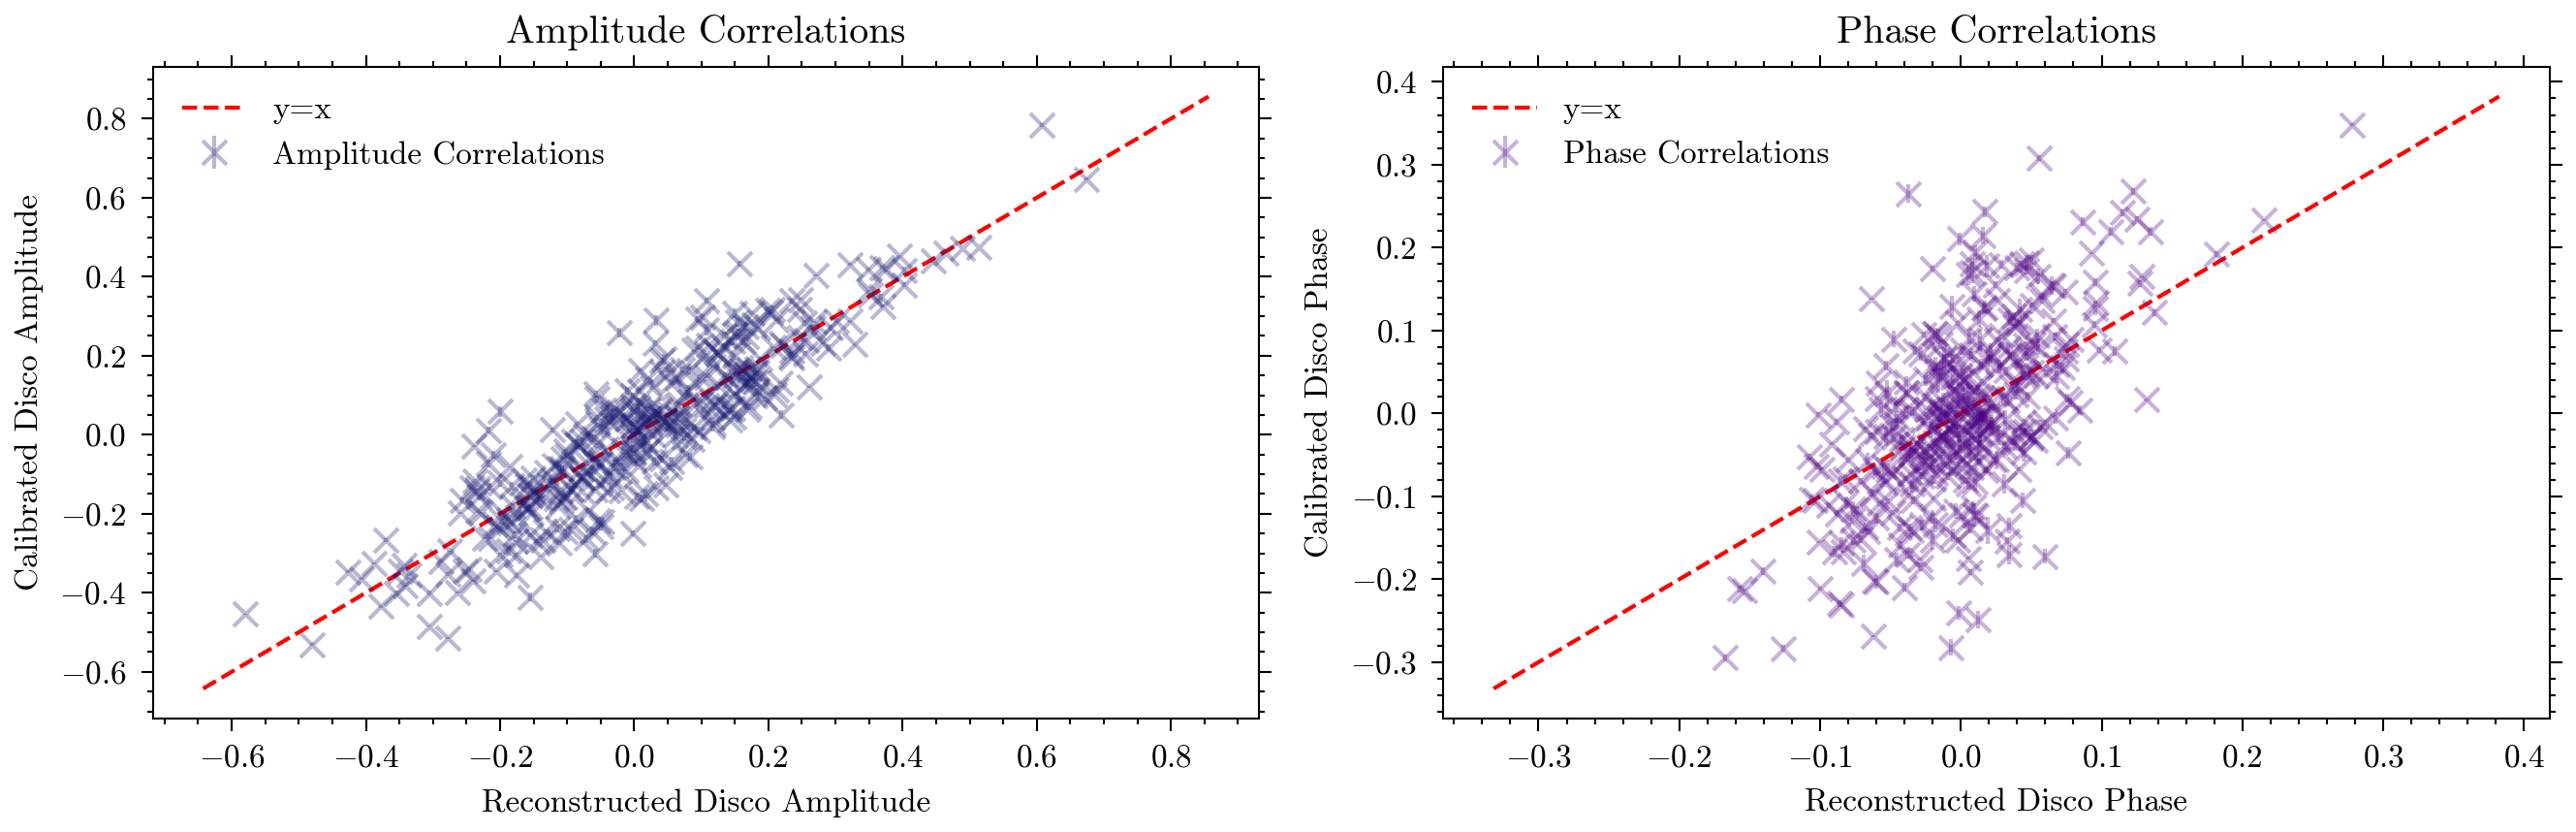

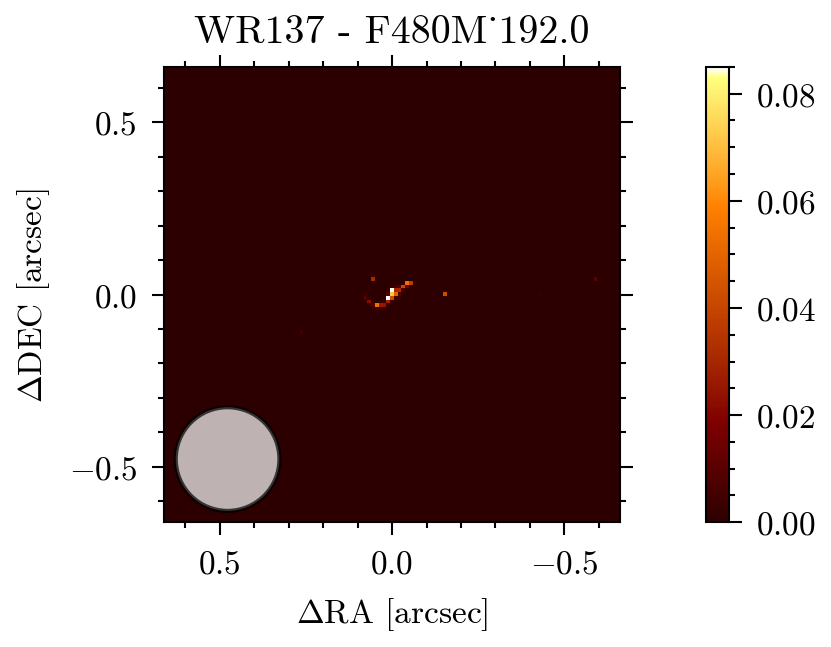

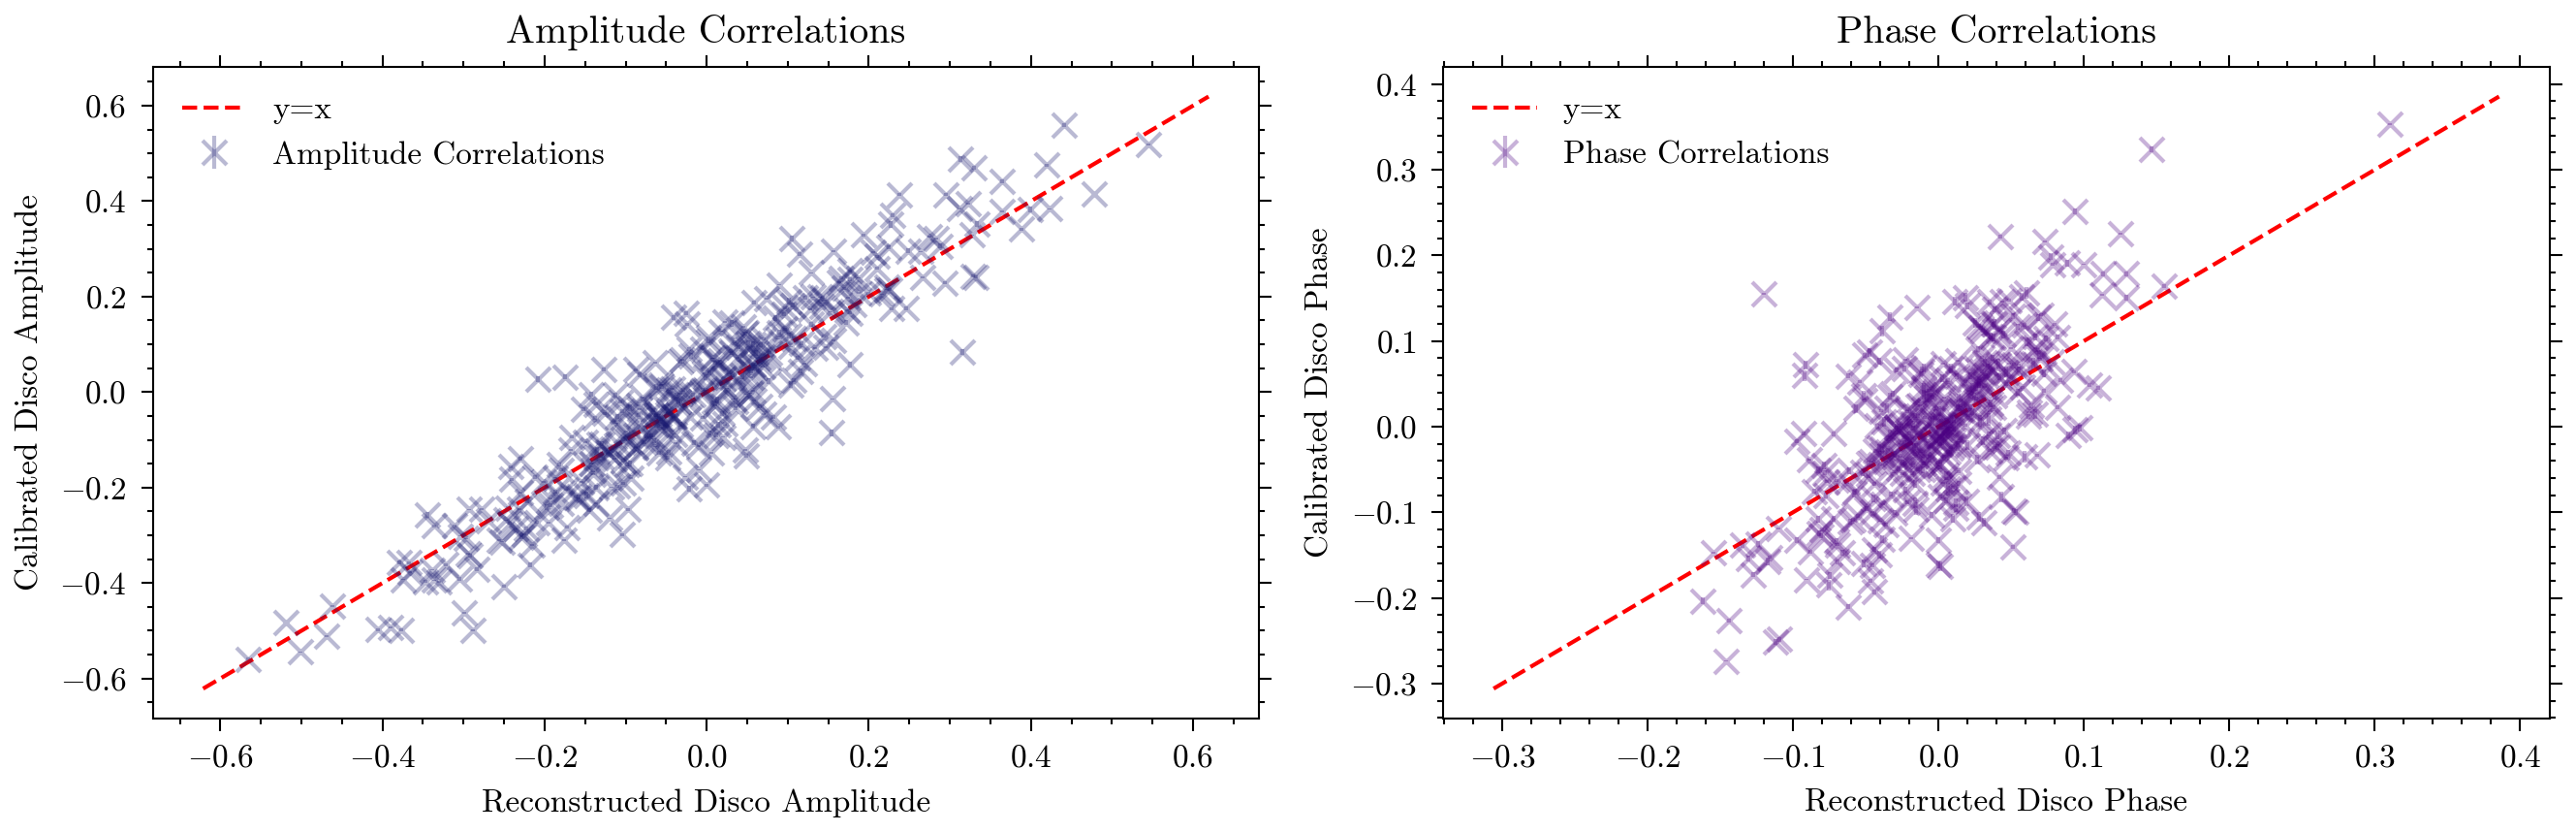

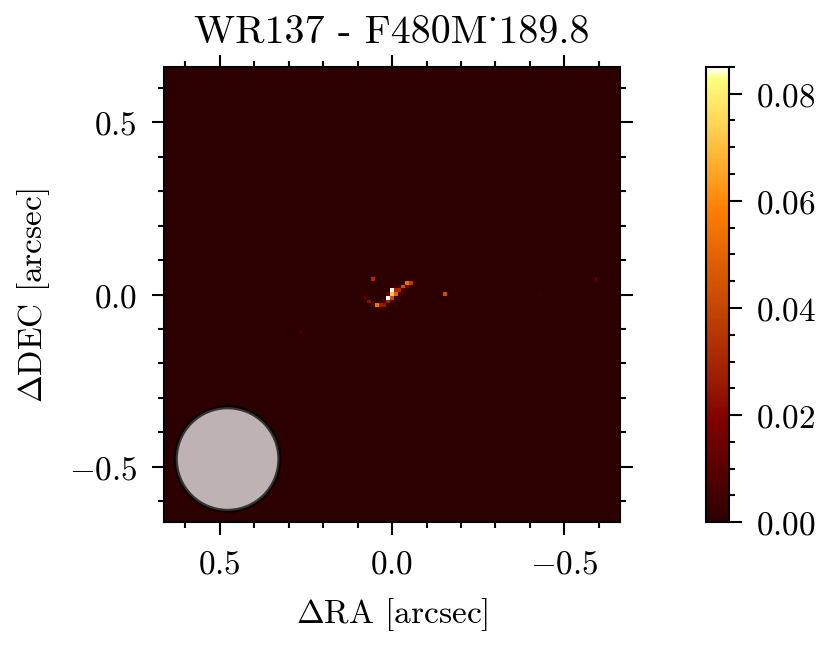

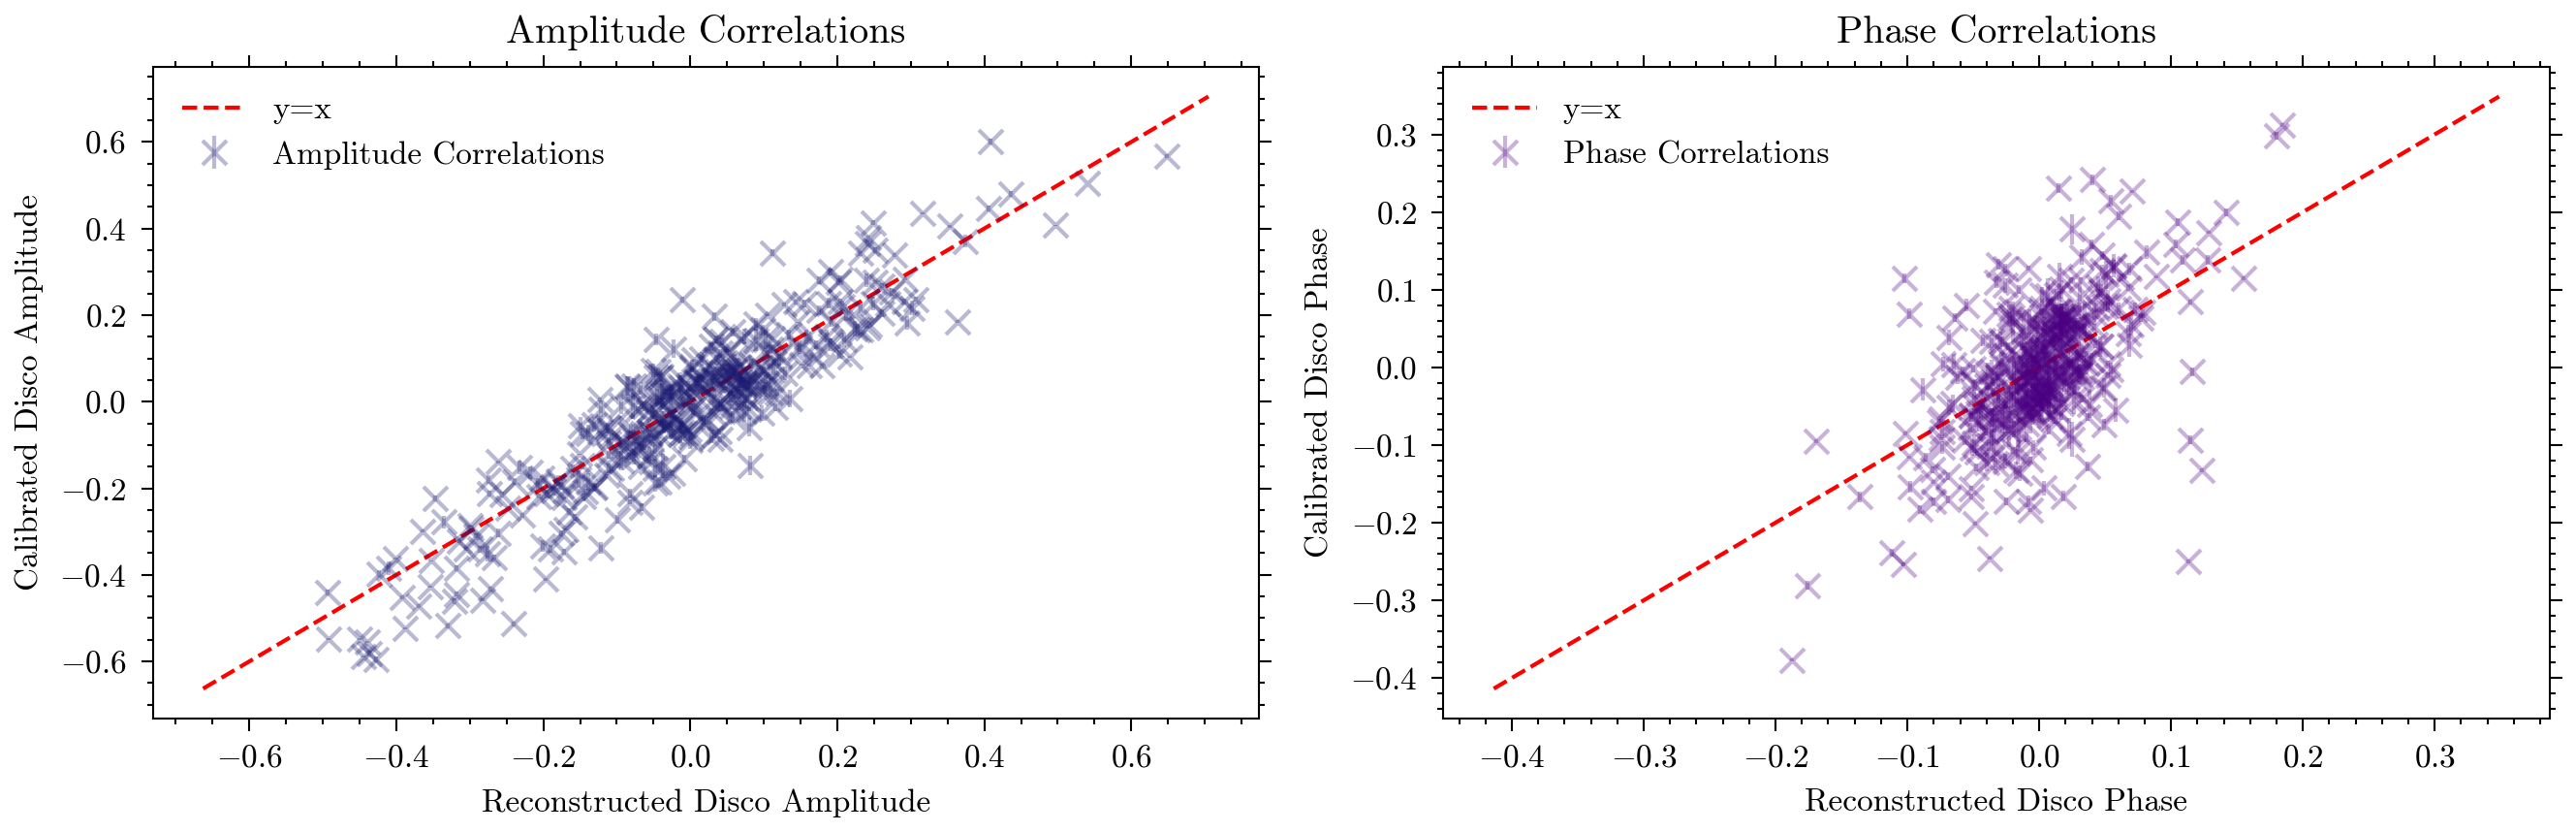

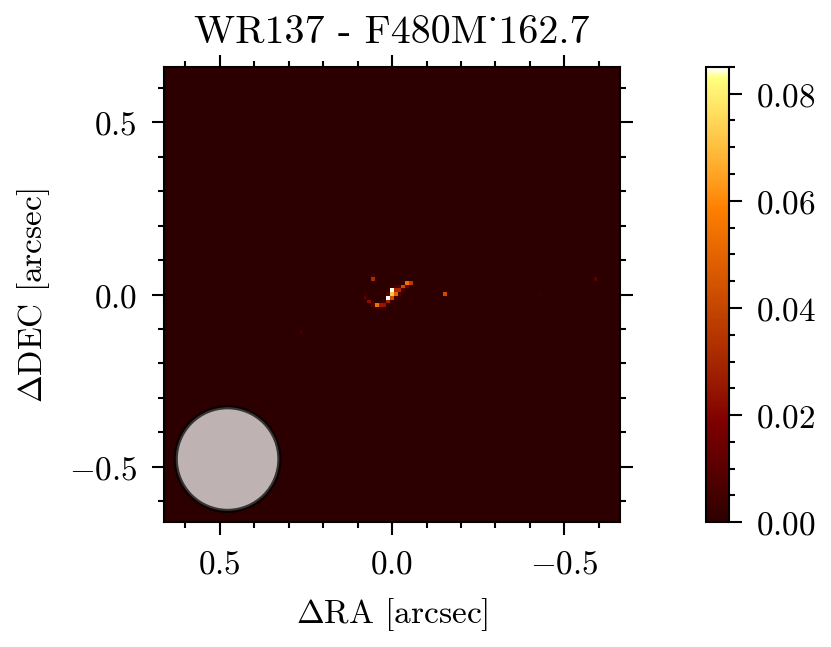

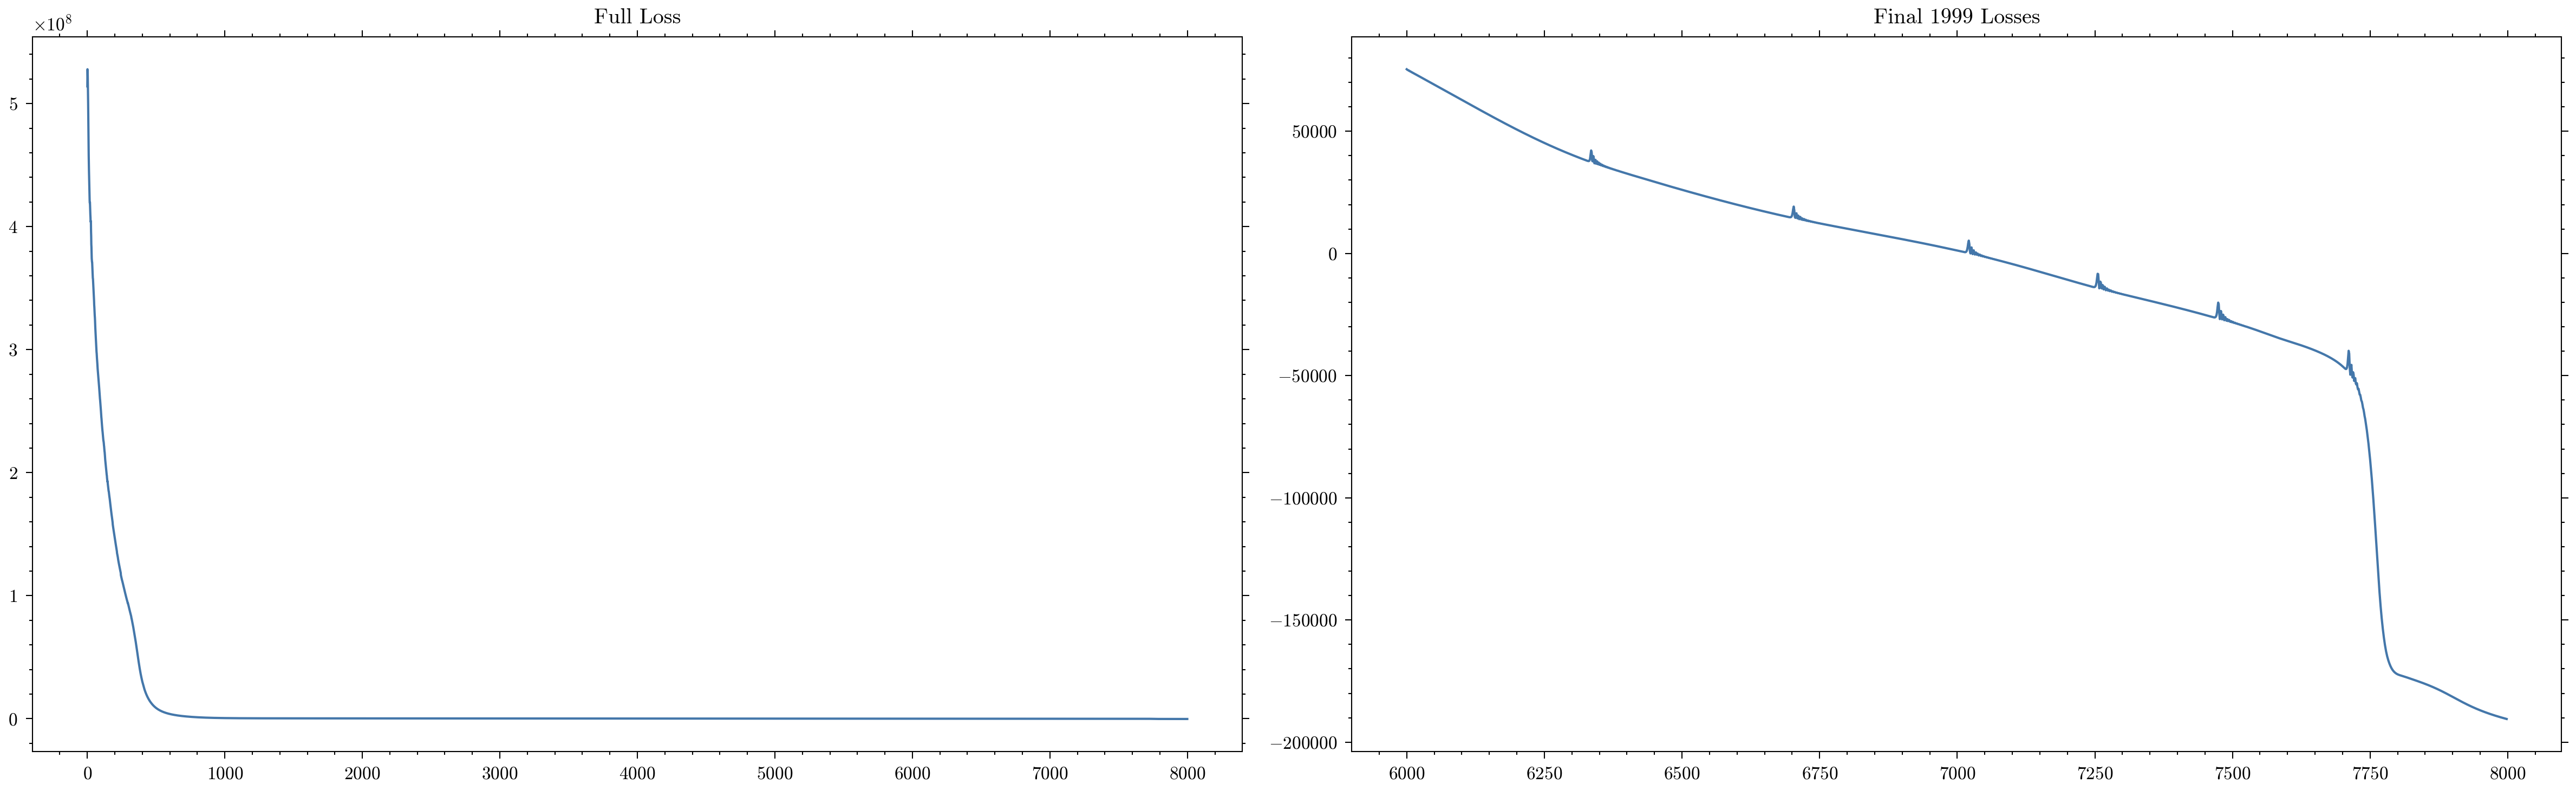

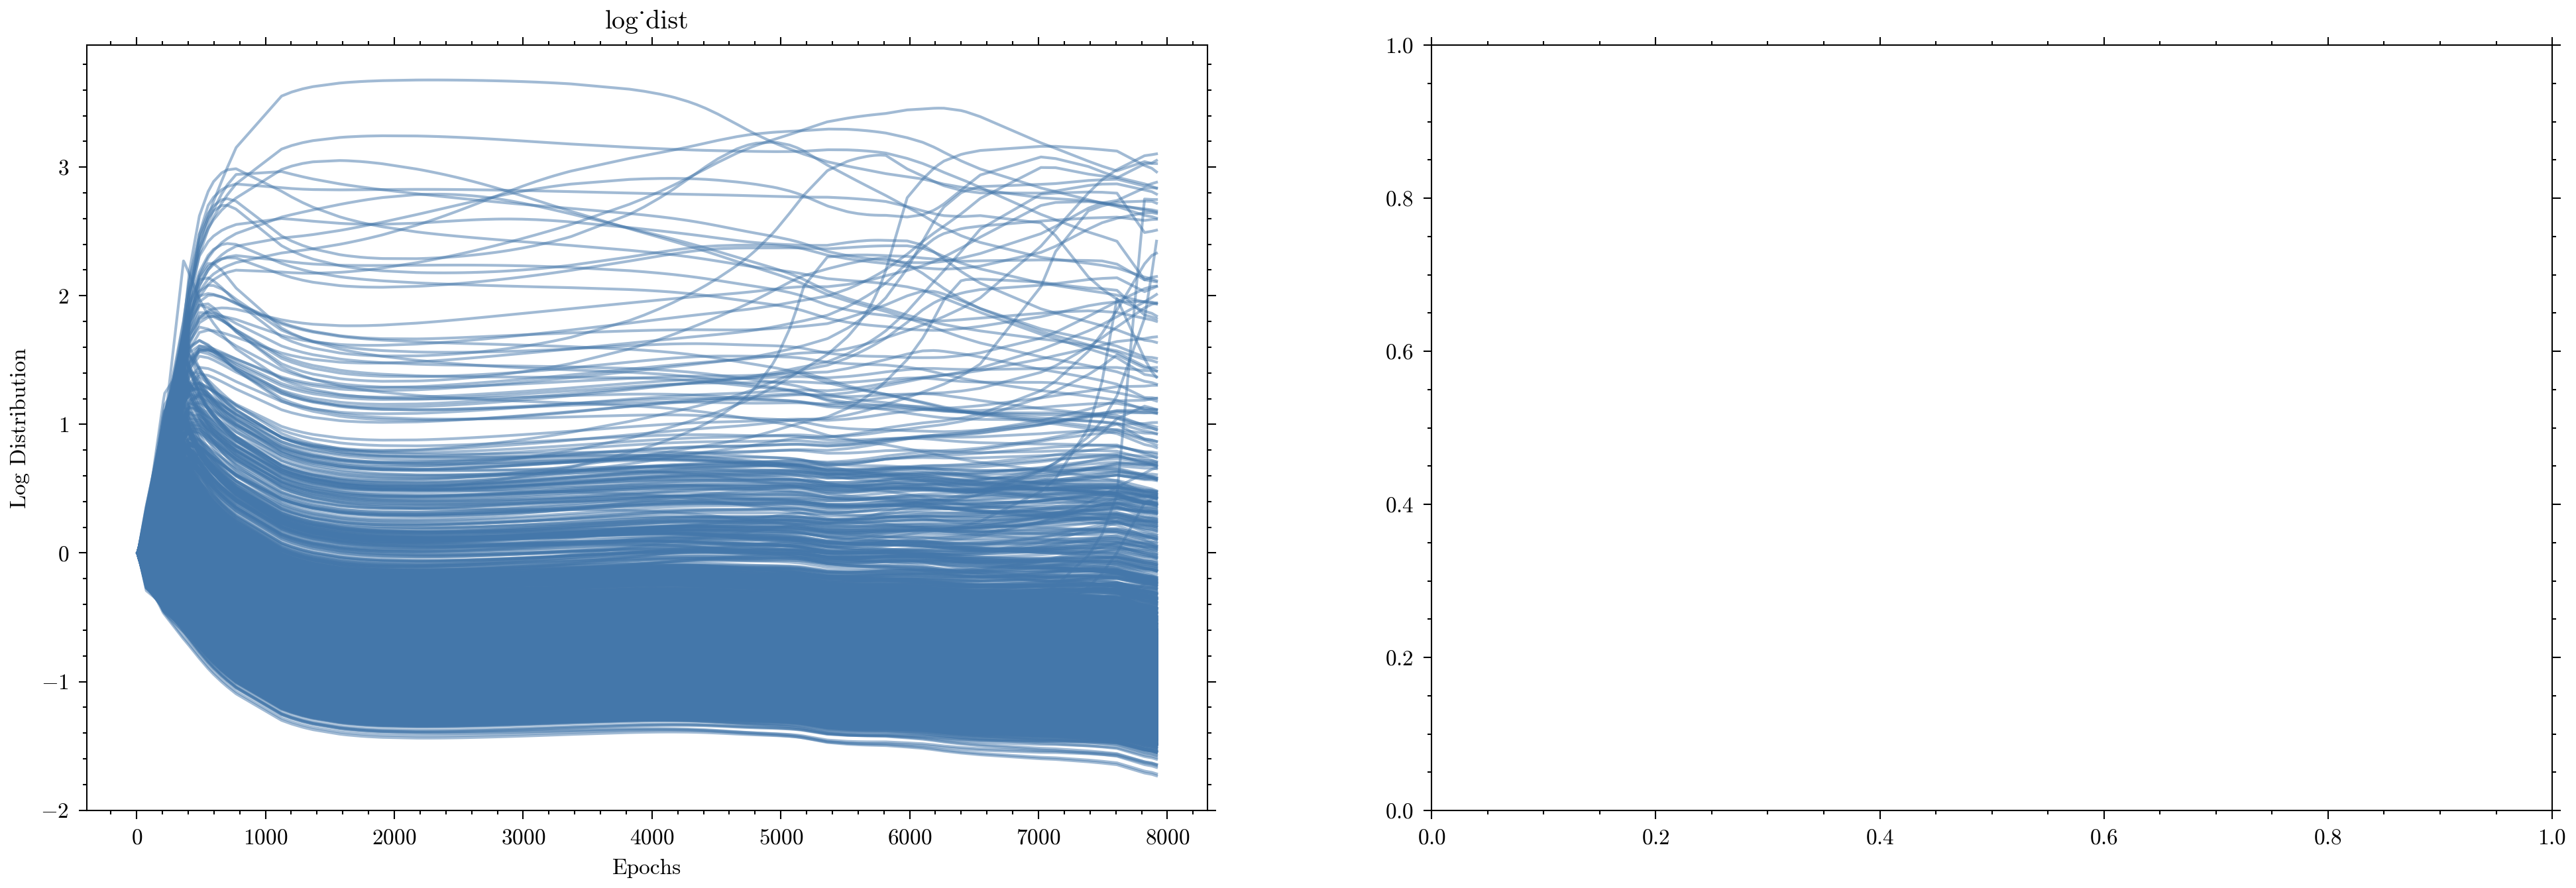

In [ ]:
from amigo import plotting

for oi in ois:
    dist = result.model.get_distribution(oi, rotate=False)

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        # power=0.3,
        # vmin=0,
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
        # scale=1.0,
    )

    fig.colorbar(c0)

    ax.set(title=f"WR137 - {oi.key}")  #   xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

In [ ]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = dorito.stats.regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [
            dorito.stats.disco_regularised_loss_fn(model, exp, reg_args)[0]
            for exp in exps
        ]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        # phase centre prior
        centre = phase_centre(model, exps[0])
        centre_prior = -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=1e-3)

        return loss + sum_prior + centre_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol)
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [ ]:
final_model = result.model


# bfgs_model = BFGS_logdist(
#     final_model,
#     # model,
#     ois,
#     args,
#     Solver=optx.BFGS,
#     max_steps=2**16,
#     rtol=1e-5,
#     atol=1e-5,
# )


bfgs_model = joint_solve(
    final_model,
    ois,
    args,
    Solver=optx.BFGS,
    max_steps=2**14,
    rtol=1e-4,
    atol=1e-4,
)

No exposures for filter F380M, skipping initialisation.
No exposures for filter F430M, skipping initialisation.
F480M_192.0
F480M_189.8
F480M_162.7


Initial loss: -110590.28856439154
Final loss: -463951.00920156646
16384 1861
The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.



In [ ]:
bfgs_model

ResolvedDiscoModel(
  params={
    'base_uv': {'F480M': c128[102,102]}, 'log_dist': {'F480M': f64[121,121]}
  },
  uv_npixels=102,
  uv_pscale=f64[],
  oversample=6.0,
  psf_pixel_scale=0.065524085
)

In [ ]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

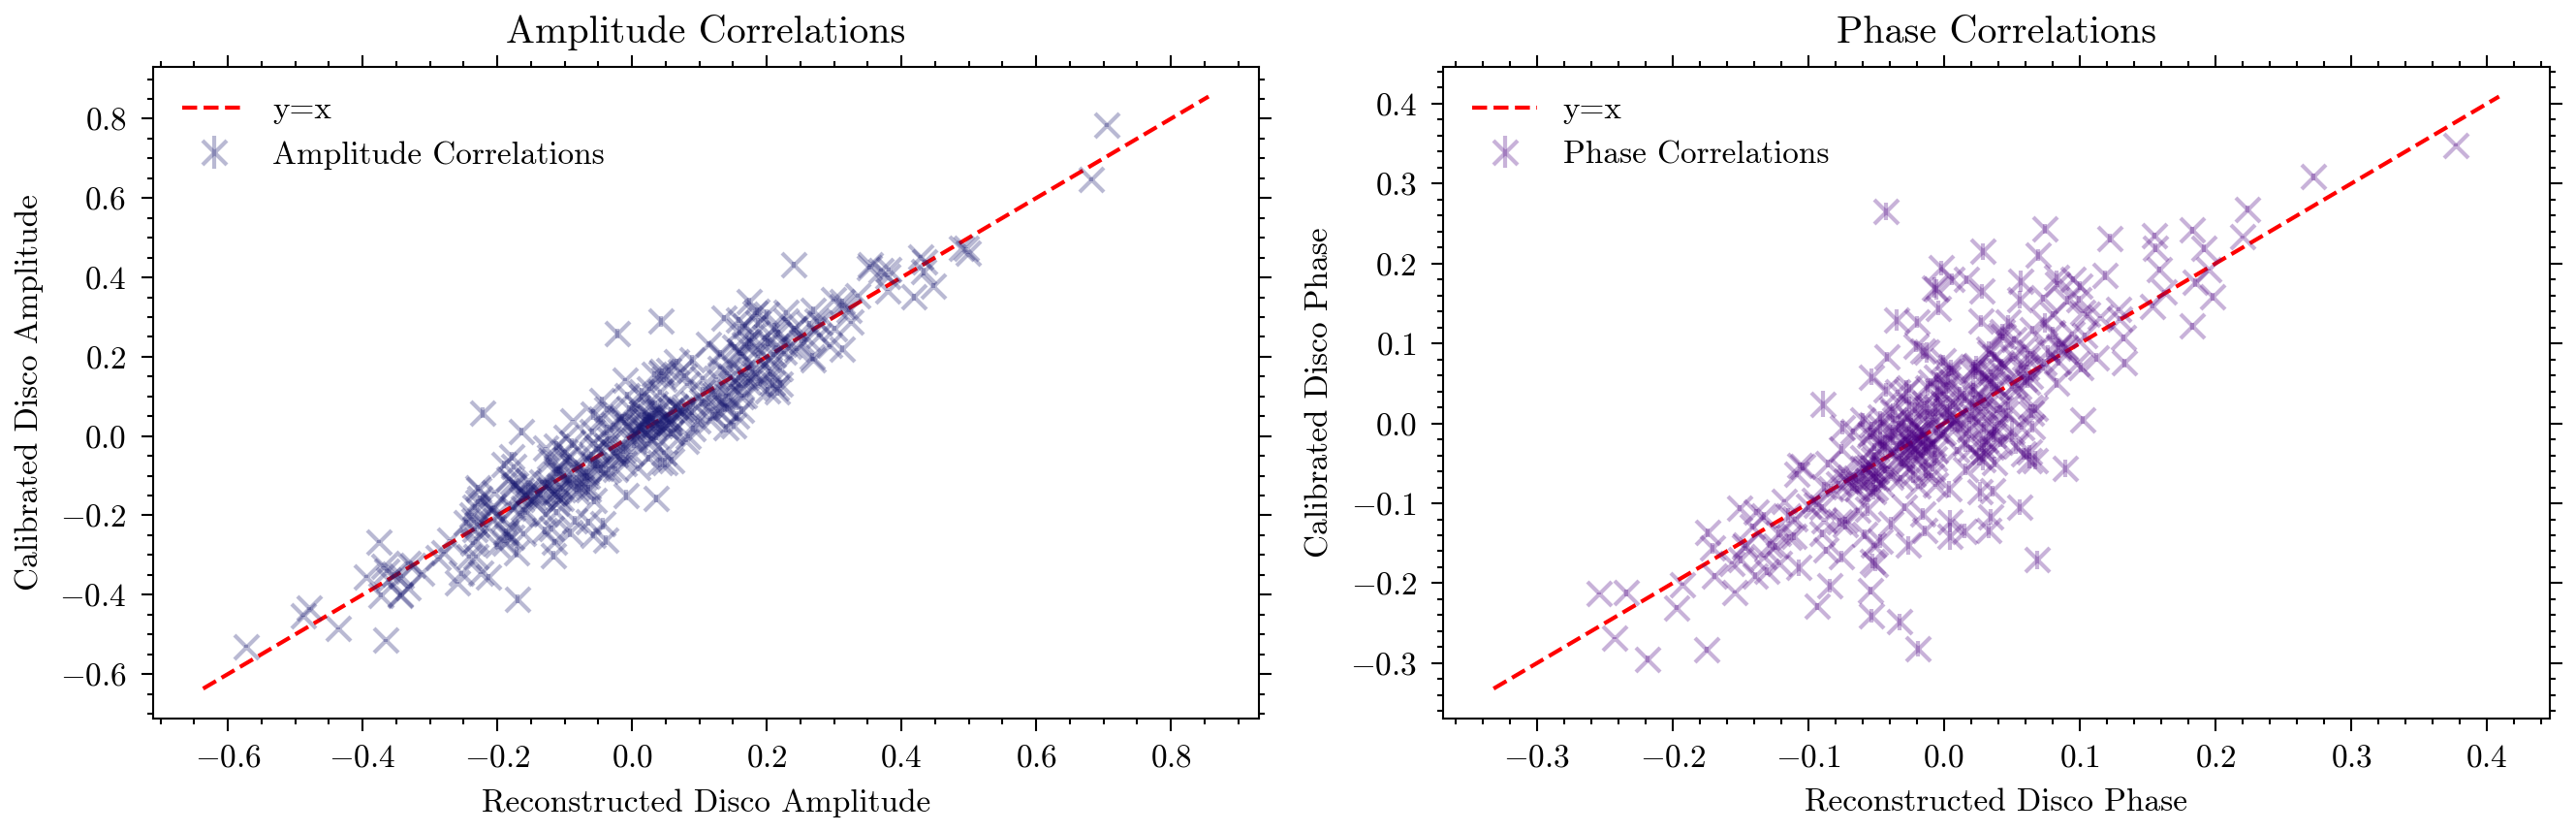

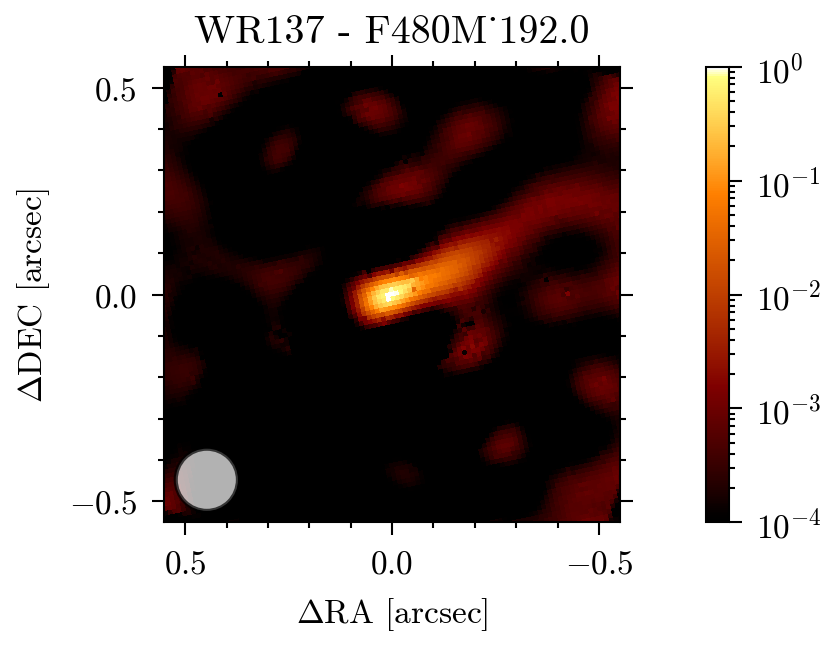

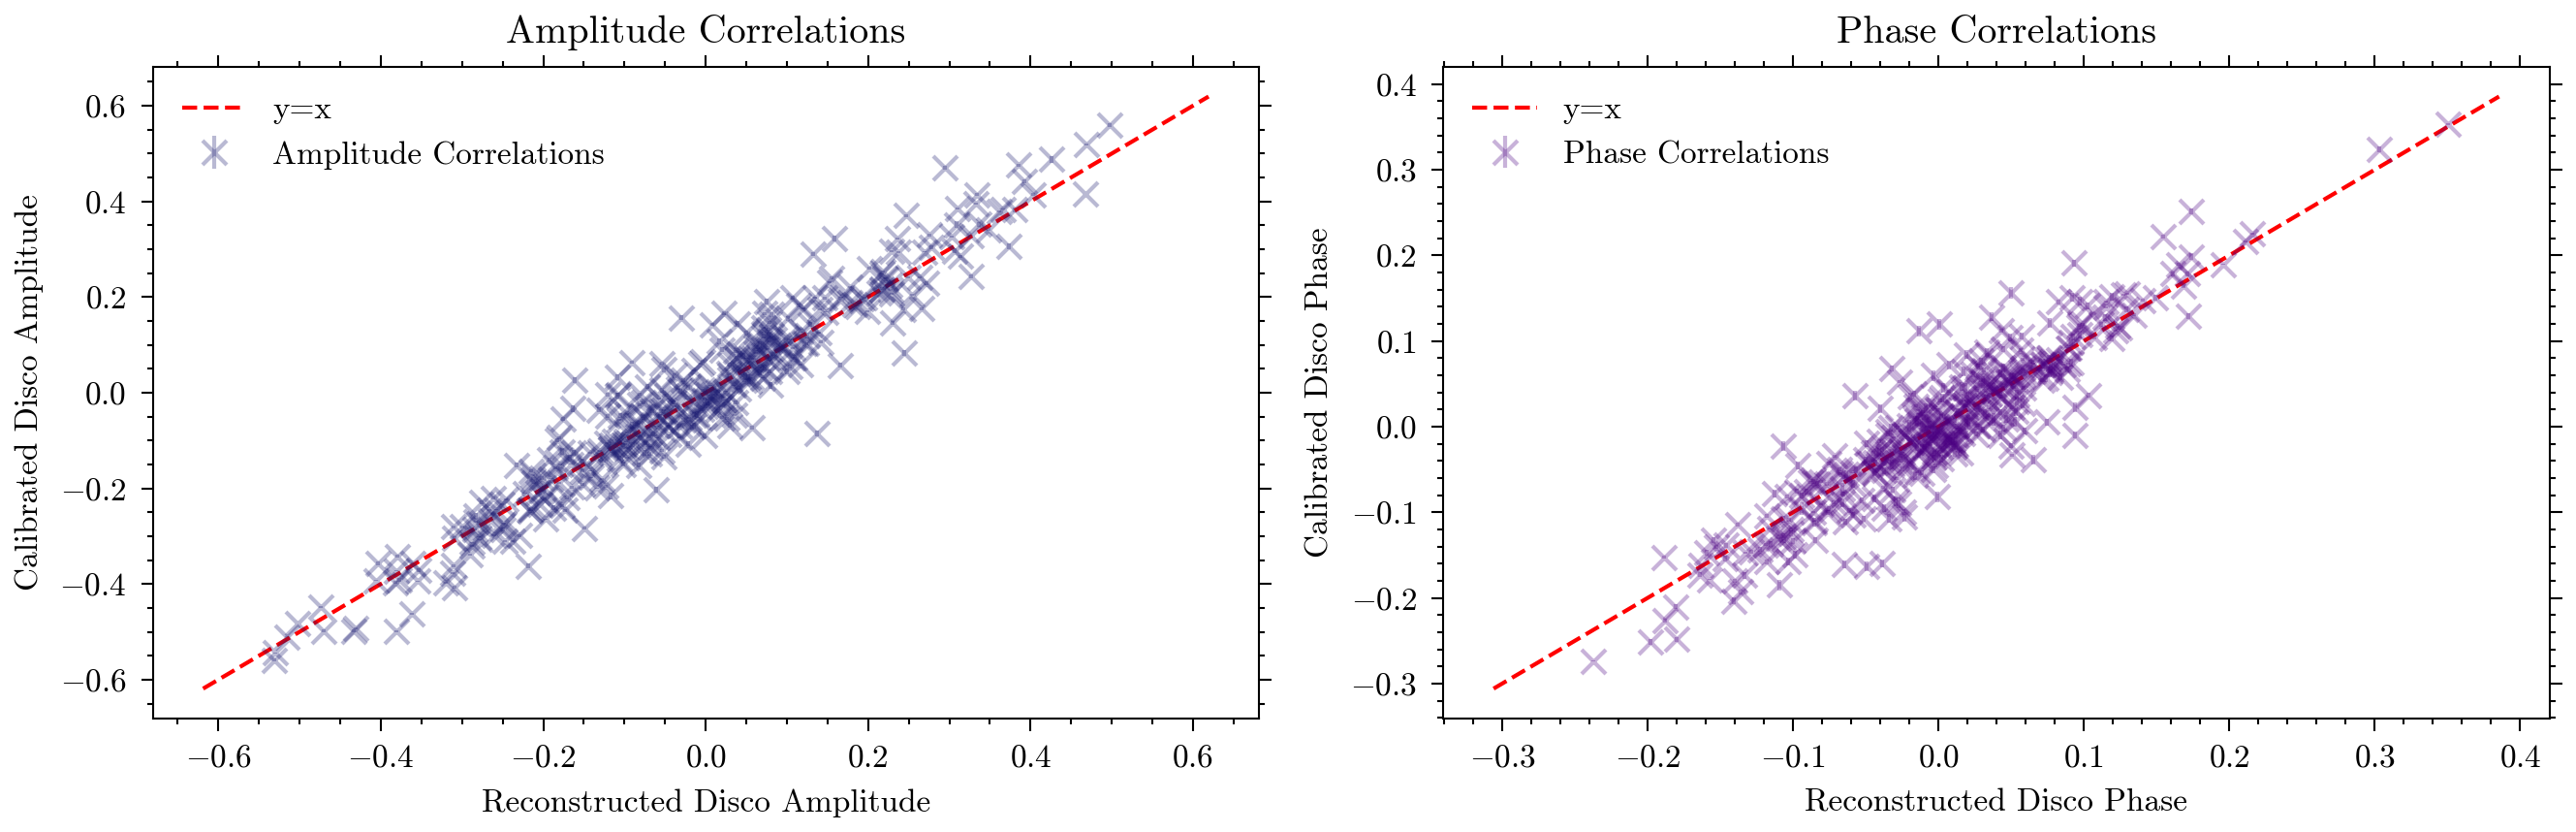

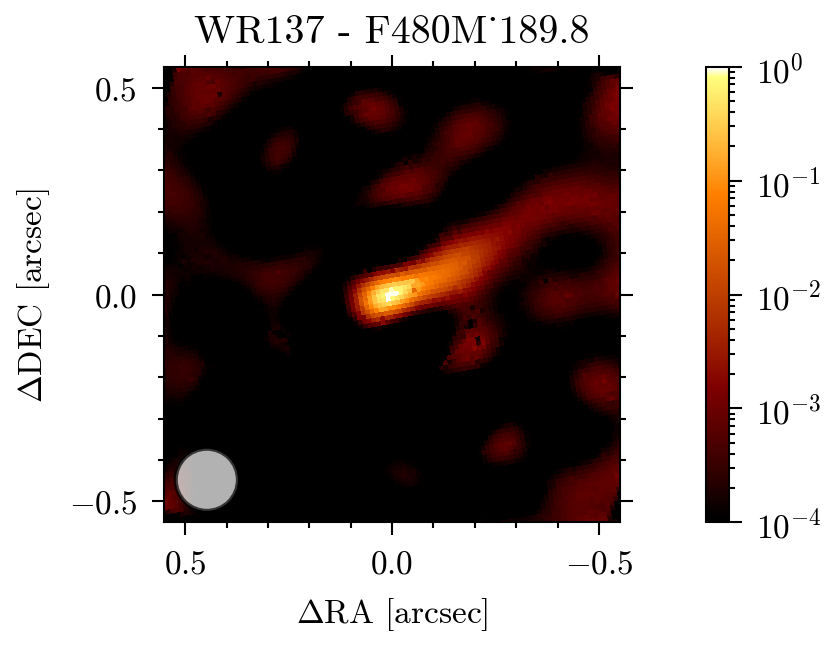

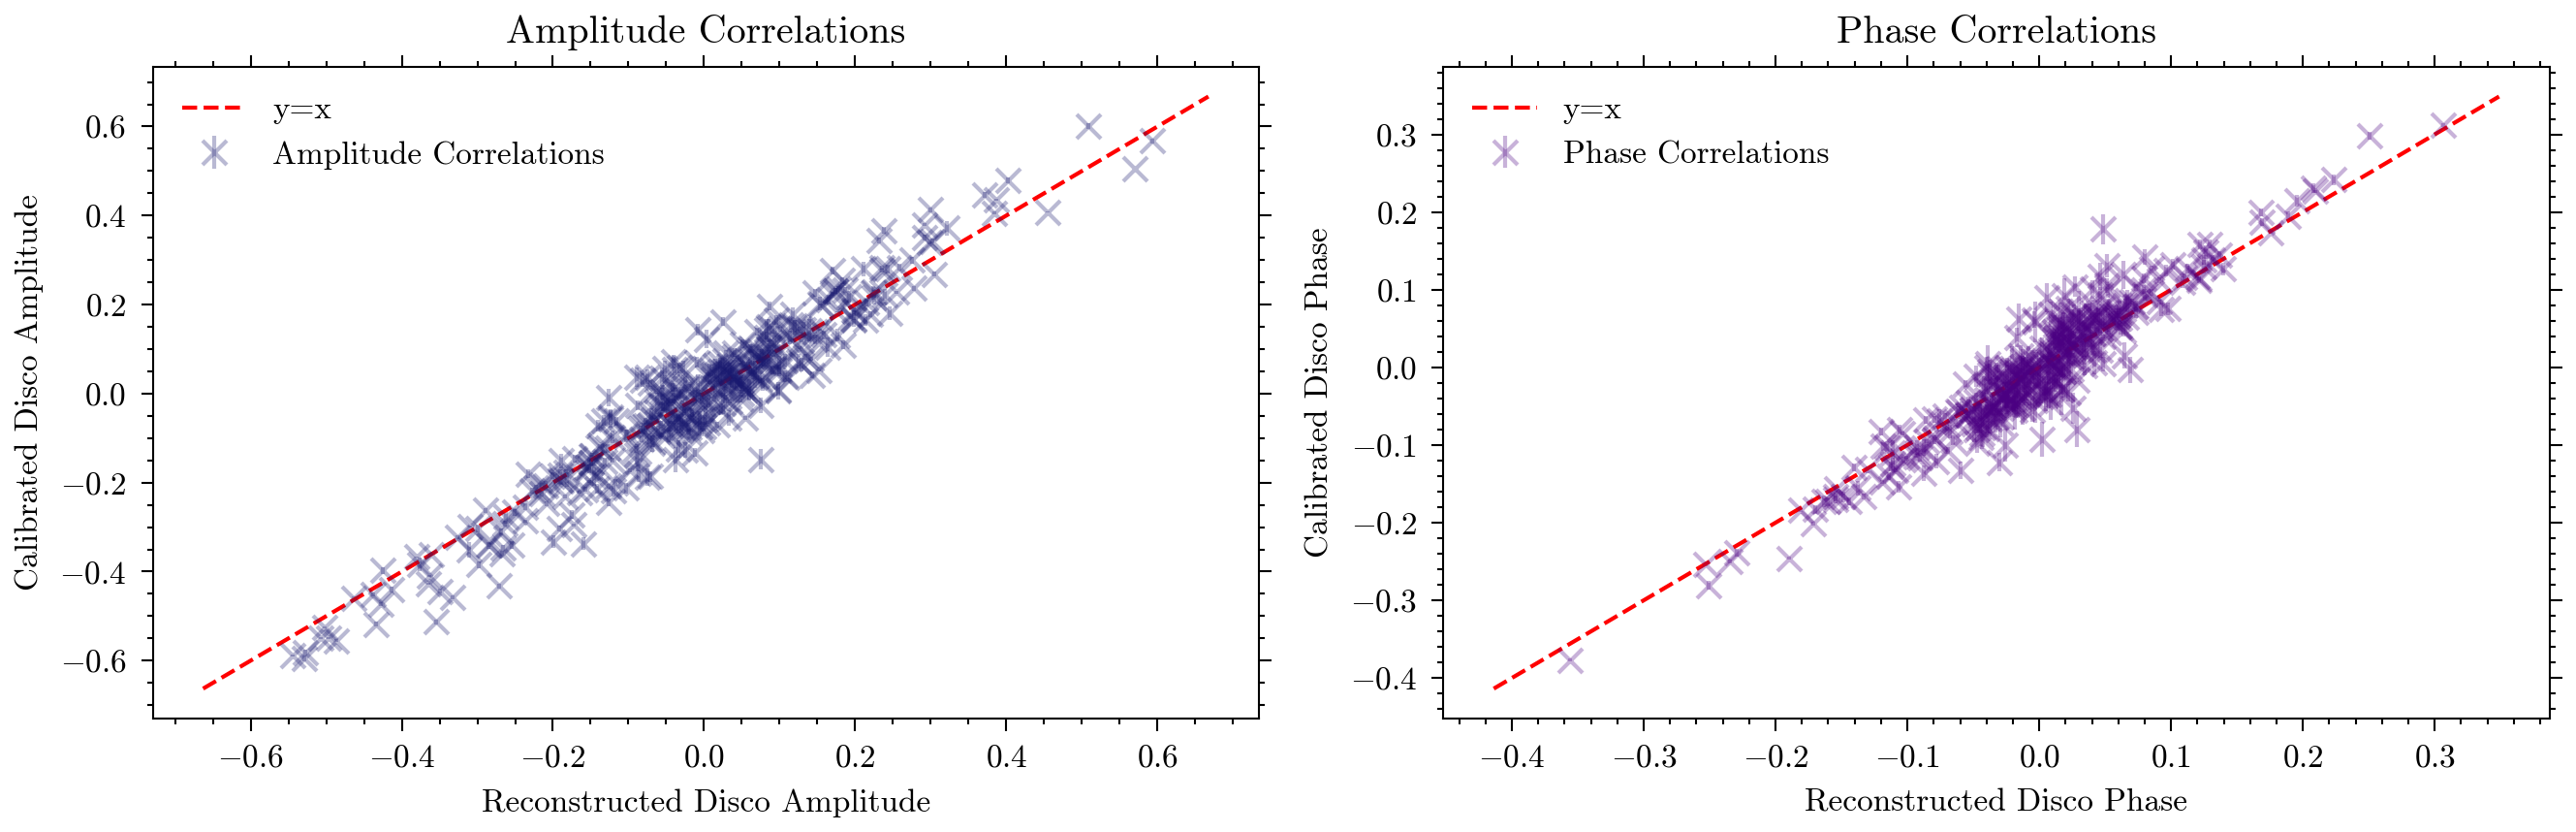

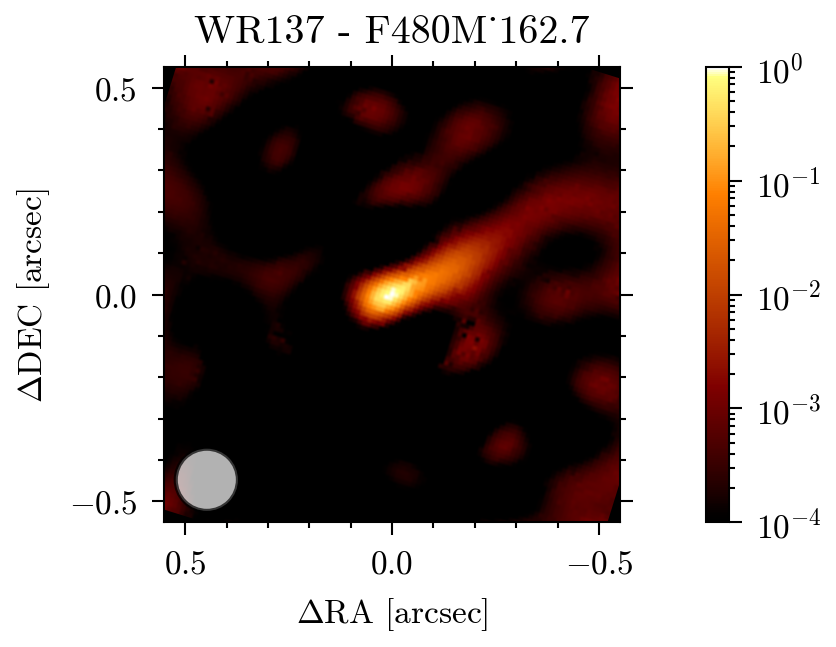

In [ ]:
for oi in ois:
    dist = bfgs_model(oi)
    dist = dist / dist.max()

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        norm=mpl.colors.LogNorm(vmin=1e-4),
        # norm=mpl.colors.PowerNorm(0.5),
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter) / 2,
        roll_angle_degrees=-oi.parang,
        scale=1.2,
    )

    fig.colorbar(c0)

    ax.set(title=f"WR137 - {oi.key}")  #   xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

# plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
# plotting.plot(result.history)

In [ ]:
for filt in ["F380M", "F480M"]:

    dist = 10 ** bfgs_model.params["log_dist"][filt]

    dist /= dist.max()

    scale = 1.0

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c1 = plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="inferno",
        norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0),
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter) / 2,
        scale=scale,
    )
    ax.set(
        title=f"WR137 - {filt}",
        xticks=[-1, -0.5, 0, 0.5, 1],
        yticks=[-1, -0.5, 0, 0.5, 1],
    )
    fig.colorbar(c1)
    plt.show()

KeyError: 'F380M'

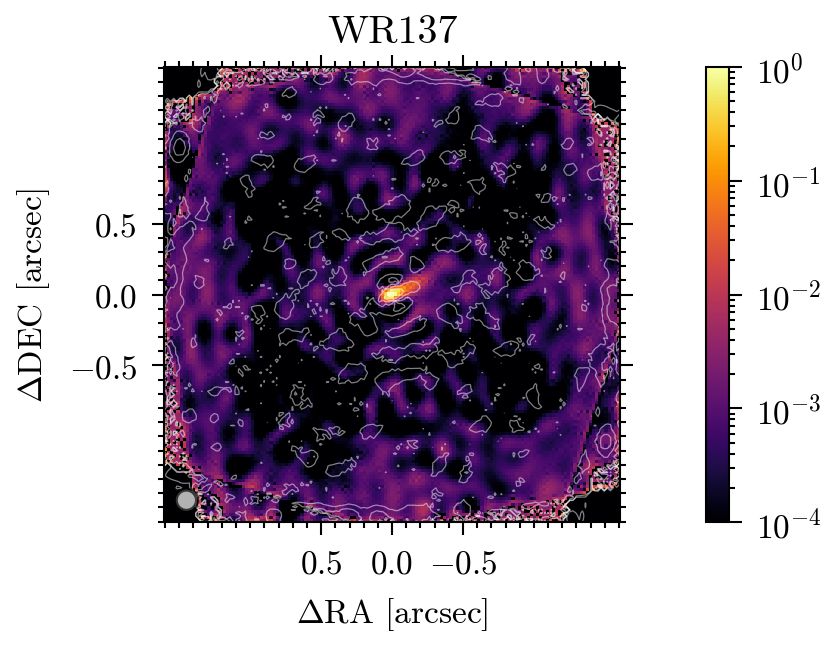

In [ ]:
dist1 = 10 ** bfgs_model.params["log_dist"]["F480M"]
dist2 = 10 ** bfgs_model.params["log_dist"]["F380M"]

dist1 /= dist1.max()
dist2 /= dist2.max()

scale = 1.0

fig, ax = plt.subplots(figsize=(6, 2.3))

c1 = plot_result(
    ax,
    dist1,
    pixel_scale=dlu.rad2arcsec(model.pscale_in),
    cmap="inferno",
    norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0),
    diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter) / 2,
    scale=scale,
)
fig.colorbar(c1)

c2 = ax.contour(
    dist2,
    extent=get_arcsec_extents(dlu.rad2arcsec(model.pscale_in) / scale, dist2.shape),
    levels=dist2.max() * np.logspace(-4, 0, 6),
    colors="white",
    linewidths=0.3,
    alpha=0.5,
    linestyles="solid",
)
# fig.colorbar(c2)

rotation_transform = mpl.transforms.Affine2D().scale(scale)
trans_data = rotation_transform + ax.transData  # creating transformation
c2.set_transform(trans_data)  # applying transformation to image


# ax.clabel(c2)
ax.set_aspect("equal")
ax.set(title=f"WR137")  #   xticks=ticks, yticks=ticks)

plt.tight_layout()
plt.show()